In [3]:
from helpers import Prior, train
from lampe.data import H5Dataset,JointDataset
from orbitize import DATADIR, read_input
import torch.nn as nn
import zuko 
import argparse


In [4]:
8192*2*2*2

65536

In [5]:
trainset = H5Dataset(f'/home/ps/4T/npe-astrometry-betapic/datasets/betapic_1600w-train.h5', batch_size=32768, shuffle=True)  
validset = H5Dataset(f'/home/ps/4T/npe-astrometry-betapic/datasets/betapic-test.h5', batch_size=2048, shuffle=True)

priors = Prior() # Needed to post-process the data in the training phase

num_obs = 2*(len(read_input.read_file('{}/betaPic.csv'.format(DATADIR))) - 1) # The RV observation is discarded

In [6]:
priors = Prior() 

In [7]:
priors.pre_process(trainset[1:2048][0]).cuda().shape

torch.Size([2047, 8])

In [8]:
def build_model_from_kwargs(filename=None, settings=None, **kwargs):
    """
    Returns the built model (from settings file or rebuild from file). Extracts the relevant arguments (normalizing flow
    or continuous flow) from setting.

    Parameters
    ----------
    filename
    settings
    kwargs

    Returns
    -------

    """
    # either filename or settings must be provided
    assert filename is not None or settings is not None

    models_dict = {
        "normalizing_flow": NormalizingFlow,
        "flow_matching": FlowMatching,
        "score_matching": ConsistencyModel,
    }

    if filename is not None:
        d = torch.load(filename, map_location="cpu")
        type = d["metadata"]["train_settings"]["model"]["type"]
    else:
        type = settings["train_settings"]["model"]["type"]

    if not type.lower() in models_dict:
        raise ValueError("No valid posterior model specified.")

    model = models_dict[type.lower()]
    # TODO copy the relevant posterior model arguments to posterior model and delete
    # TODO non-necessary arguments currently keeps all arguments for flow_matching and
    # TODO score_matching, e.g., sigma_min for score_matching
    # delete and or modify parameter file.
    if settings is not None:
        if type.lower() == "normalizing_flow":
            settings["train_settings"]["model"]["posterior_kwargs"].update(
                settings["train_settings"]["model"].get("nf_kwargs", {})
            )

        if type.lower() in ["flow_matching", "score_matching"]:
            settings["train_settings"]["model"]["posterior_kwargs"].update(
                settings["train_settings"]["model"].get("cf_kwargs", {})
            )

        # if type.lower() in ["flow_matching", "score_matching"]:
        if "nf_kwargs" in settings["train_settings"]["model"].keys():
            del settings["train_settings"]["model"]["nf_kwargs"]
        # if type.lower() == "normalizing_flow":
        if "cf_kwargs" in settings["train_settings"]["model"].keys():
            del settings["train_settings"]["model"]["cf_kwargs"]

    return model(model_filename=filename, metadata=settings, **kwargs)


def autocomplete_model_kwargs(
    model_kwargs, data_sample=None, input_dim=None, context_dim=None
):
    """
    Autocomplete the model kwargs from train_settings and data_sample from
    the dataloader:
    (*) set input dimension of embedding net to shape of data_sample[1]
    (*) set dimension of nsf parameter space to len(data_sample[0])
    (*) set added_context flag of embedding net if required for gnpe proxies
    (*) set context dim of nsf to output dim of embedding net + gnpe proxy dim

    :param train_settings: dict
        train settings as loaded from .yaml file
    :param data_sample: list
        Sample from dataloader (e.g., wfd[0]) used for autocomplection.
        Should be of format [parameters, GW data, gnpe_proxies], where the
        last element is only there is gnpe proxies are required.
    :return: model_kwargs: dict
        updated, autocompleted model_kwargs
    """

    # If provided, extract settings from the data sample. Otherwise, use provided kwargs. Since input_dim always needs
    # to be provided, we can use this to verify that they are mutually exclusive.
    assert (
        data_sample is not None
        and input_dim is None
        or data_sample is None
        and input_dim is not None
    )

    if data_sample is not None:
        # set input dims from ifo_list and domain information
        model_kwargs["embedding_kwargs"]["input_dims"] = list(data_sample[1].shape)
        # set dimension of parameter space of nsf
        model_kwargs["posterior_kwargs"]["input_dim"] = len(data_sample[0])
        # set added_context flag of embedding net if gnpe proxies are required
        # set context dim of nsf to output dim of embedding net + gnpe proxy dim
        try:
            gnpe_proxy_dim = len(data_sample[2])
            model_kwargs["embedding_kwargs"]["added_context"] = True
            model_kwargs["posterior_kwargs"]["context_dim"] = (
                model_kwargs["embedding_kwargs"]["output_dim"] + gnpe_proxy_dim
            )
        except IndexError:
            model_kwargs["embedding_kwargs"]["added_context"] = False
            model_kwargs["posterior_kwargs"]["context_dim"] = model_kwargs[
                "embedding_kwargs"
            ]["output_dim"]
    else:
        model_kwargs["posterior_kwargs"]["input_dim"] = input_dim
        model_kwargs["posterior_kwargs"]["context_dim"] = context_dim

In [9]:
import argparse
import csv
import math
from os.path import join

import matplotlib.pyplot as plt
import torch
import numpy as np
import yaml
from torch.utils.data import Dataset
from posterior_models.flow_matching import FlowMatching
from posterior_models.normalizing_flow import NormalizingFlow 
from posterior_models.score_matching import ConsistencyModel

In [10]:
with open("/home/ps/4T/npe-astrometry-betapic/traing_4/settings.yaml") as f:
    settings = yaml.safe_load(f)

In [11]:
autocomplete_model_kwargs(
    settings["model"],
    input_dim=8, # input = theta dimension
    context_dim=68,  # context dim = observation dimension
)

In [12]:
model = build_model_from_kwargs(
    settings={"train_settings": settings},
    device=settings["training"].get("device", "cuda"),
)

Putting posterior model to device cuda.


In [13]:
model.optimizer_kwargs = settings["training"]["optimizer"]
model.scheduler_kwargs = settings["training"]["scheduler"]
model.initialize_optimizer_and_scheduler()

In [14]:
from utils import build_train_and_test_loaders, RuntimeLimits

In [15]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from typing import Union, Tuple, Iterable


In [16]:
train_loader = DataLoader(trainset, batch_size=None, shuffle=False)
test_loader = DataLoader(validset, batch_size=None, shuffle=False)

In [17]:
for batch_idx, data in enumerate(test_loader):
    print(data[0].shape)

torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])
torch.Size([2048, 8])


In [18]:
runtime_limits = RuntimeLimits(
    epoch_start=0,
    max_epochs_total=settings["training"]["epochs"],
)

In [19]:
# from helpers import Simulator, Prior
# import argparse
# from orbitize import read_input, DATADIR
# from orbitize.system import seppa2radec, transform_errors
# from lampe.data import H5Dataset, JointLoader
# data_table = read_input.read_file('{}/betaPic.csv'.format(DATADIR))

# # Discard the  RV observation, as we do not take it into account in the model
# data_table = data_table[:-1] 

# # Transform the values that are currently in the sep/pa format to the ra/dec format. 
# # Note that the function transforming the errors is not vectorisable but it is not 
# # such a problem because it is only for +- 30 values
# ra_errs = []
# dec_errs = []
# corrs = []
# ra, dec = seppa2radec(data_table["quant1"], data_table["quant2"])

# for i in range(len(data_table)):
#     ra_err, dec_err, corr = transform_errors(data_table["quant1"][i], 
#                                             data_table["quant2"][i], 
#                                             data_table["quant1_err"][i], 
#                                             data_table["quant2_err"][i], 
#                                             data_table["quant12_corr"][i], 
#                                             seppa2radec)
#     ra_errs.append(ra_err)
#     dec_errs.append(dec_err)
#     corrs.append(corr)

# data_table["quant1"] = ra
# data_table["quant2"] = dec
# data_table["quant1_err"] = ra_errs
# data_table["quant2_err"] = dec_errs
# data_table["quant12_corr"] = corr
# data_table["quant_type"] = ["radec" for _ in range(len(data_table))]

# # Define the prior & simulator
# priors = Prior()
# simulator = Simulator(data_table)

# loader = JointLoader(priors, simulator, batch_size=32768, vectorized=True, num_workers=32)

In [20]:
trainset.__len__()

16777216

In [21]:
32768

32768

In [ ]:
model.train(
    train_loader,
    test_loader ,
    train_dir='/home/ps/4T/npe-astrometry-betapic/traing_4',
    runtime_limits=runtime_limits,
    early_stopping=True, 
    use_wandb=None,
)

In [24]:
model.load_model('/home/ps/4T/npe-astrometry-betapic/traing_4/best_model.pt')

Putting posterior model to device cuda.


In [57]:
import random
import tqdm
from scipy import stats
from tqdm import tqdm
import matplotlib.pyplot as plt 
neval = 5000# number of injections
percentiles1 = np.empty((5000 ,8))
nparams = 8
# percentiles2 = np.empty((neval, nparams))
for idx in tqdm(range(neval)):


    with torch.no_grad():
        model.network.eval()
        data = validset[idx][1]
        data = data.repeat(1024, 1).to(device)
        posterior_samples = model.sample_batch(data)
        valid_rows = (posterior_samples >= -1) & (posterior_samples<= 1) 
        valid_rows = valid_rows.all(axis=1)
        posterior_samples = posterior_samples[valid_rows]
        # samples = posterior_samples.cpu().numpy()
    diffusion_samples = priors1.post_process(torch.tensor(posterior_samples).cpu())
    samples2 = np.array(diffusion_samples)
    for n in range(nparams):
        percentiles1[idx, n] = stats.percentileofscore(samples2[:,n], validset[idx][0][n])

  8%|▊         | 403/5000 [00:46<08:51,  8.65it/s]

dopri8
1e-8
dopri8
1e-8


  8%|▊         | 405/5000 [00:46<08:41,  8.80it/s]

dopri8
1e-8
dopri8
1e-8


  8%|▊         | 407/5000 [00:46<08:38,  8.86it/s]

...

100%|█████████▉| 4997/5000 [09:30<00:00,  8.90it/s]

dopri8
1e-8
dopri8
1e-8


100%|█████████▉| 4999/5000 [09:30<00:00,  8.24it/s]

dopri8
1e-8
dopri8
1e-8


100%|██████████| 5000/5000 [09:30<00:00,  8.76it/s]


In [ ]:
import scipy
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

def make_pp(percentiles, parameter_labels, ks=True, confidence=0.95, conf_color='gray'):
    percentiles = percentiles / 100.
    nparams = percentiles.shape[-1]
    nposteriors = percentiles.shape[0]

    ordered = np.sort(percentiles, axis=0)
    ordered = np.concatenate((np.zeros((1, nparams)), ordered, np.ones((1, nparams))))
    y = np.linspace(0, 1, nposteriors + 2)

    fig = plt.figure(figsize=(6, 6))
    color = [
    '#f9f871',  # 浅黄色
    '#ff8066',  # 橙红色
    '#ff5252',  # 红色
    '#7c4dff',  # 紫色
    '#539caf',  # 蓝绿色
    '#4caf50',  # 绿色
    '#ffeb3b',  # 黄色
    '#90caf9'   # 浅蓝色
]
    for n in range(nparams):
        if ks:
            pvalue = stats.kstest(percentiles[:, n], 'uniform')[1]
            print(pvalue)
            plt.step(ordered[:, n], y,where='post', color = color[n],label=parameter_labels[n] , )
        else:
            plt.step(ordered[:, n], y, where='post', label=parameter_labels[n])
        confidence = [0.95]
        N = nposteriors-2
        for ci, j in zip(confidence, range(len(confidence))):
            edge_of_bound = (1. - ci) / 2.
            lower = scipy.stats.binom.ppf(1 - edge_of_bound, N, y) / N
            print(lower.shape)
            upper = scipy.stats.binom.ppf(edge_of_bound, N, y) / N
            print(upper.shape)
            conf_color_wheel = ['#2c73d2']
            # The binomial point percent function doesn't always return 0 @ 0,
            # so set those bounds explicitly to be sure
            lower[0] = 0
            upper[0] = 0
            plt.fill_between(y, lower, upper, facecolor=conf_color_wheel[j], alpha=0.5)

    plt.plot(y, y, 'k--')
    plt.legend()
    plt.ylabel(r'$CDF(p)$')
    plt.xlim((0, 1))
    plt.ylim((0, 1))
    plt.xlabel(r'$p$')
    ax = fig.gca()
    ax.set_aspect('equal', anchor='SW')
    plt.show()

In [82]:
LABELS = [r'$a$', r'$e$', r'$i$',
        r'$\omega$', r'$\Omega$',
        r'$\tau$', r'$\pi$', r'$M_T$']

3.161745493743059e-14
0.0035653863386048193
3.4074316100751903e-10
9.466721767984847e-08
6.216001259627801e-07
0.0014547185078378796
0.23458324039650402
0.40664929335623345


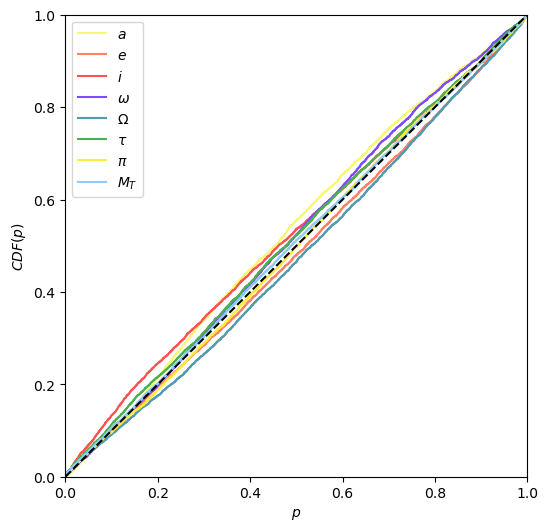

In [90]:
make_pp(percentiles1[:], parameter_labels=LABELS , ks=True, confidence=[0.95])